# 🎵 Spotify ML Pipeline
## End-to-End Machine Learning Analysis
**Goal:** Predict whether a Spotify track will be popular based on its audio features.

### Pipeline:
1. 📊 Exploratory Data Analysis (EDA)
2. 🔧 Preprocessing & Feature Engineering
3. 🔵 Clustering (K-Means)
4. 🤖 Classification (4 Models)
5. 🧠 Neural Network (TensorFlow)
6. 📈 Final Evaluation & Insights

In [1]:
# Importing the Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')


# Display settings

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')


print("All import successful")
print(f"Numpy : {np.__version__}")
print(f"Pandas : {pd.__version__}")

All import successful
Numpy : 1.23.5
Pandas : 2.0.3


In [2]:
# Loading the dataset

df = pd.read_csv('spotify.csv')

print(f"Dataset Shape : {df.shape}")
print(f"Rows          : {df.shape[0]:,}")
print(f"Columns       : {df.shape[1]}")
print(f"\nColumn Names:")
for col in df.columns:
    print(f"  → {col}")

Dataset Shape : (114000, 21)
Rows          : 114,000
Columns       : 21

Column Names:
  → Unnamed: 0
  → track_id
  → artists
  → album_name
  → track_name
  → popularity
  → duration_ms
  → explicit
  → danceability
  → energy
  → key
  → loudness
  → mode
  → speechiness
  → acousticness
  → instrumentalness
  → liveness
  → valence
  → tempo
  → time_signature
  → track_genre


In [3]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,0.000,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,0.000,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000,0.117,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,0.000,0.132,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000,0.083,0.167,119.949,4,acoustic


In [4]:
# Data Types & Missing Values
print("DATA TYPES:")
print(df.dtypes)
print(f"\nMISSING VALUES:")
print(df.isnull().sum())
print(f"\nTOTAL MISSING: {df.isnull().sum().sum()}")

DATA TYPES:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

MISSING VALUES:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness         

In [5]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,56999.500,33.239,228029.153,0.567,0.641,5.309,-8.259,0.638,0.085,0.315,0.156,0.214,0.474,122.148,3.904
std,32909.110,22.305,107297.713,0.174,0.252,3.560,5.029,0.481,0.106,0.333,0.310,0.190,0.259,29.978,0.433
min,0.000,0.000,0.000,0.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,28499.750,17.000,174066.000,0.456,0.472,2.000,-10.013,0.000,0.036,0.017,0.000,0.098,0.260,99.219,4.000
50%,56999.500,35.000,212906.000,0.580,0.685,5.000,-7.004,1.000,0.049,0.169,0.000,0.132,0.464,122.017,4.000
75%,85499.250,50.000,261506.000,0.695,0.854,8.000,-5.003,1.000,0.085,0.598,0.049,0.273,0.683,140.071,4.000
max,113999.000,100.000,5237295.000,0.985,1.000,11.000,4.532,1.000,0.965,0.996,1.000,1.000,0.995,243.372,5.000


In [6]:
# ── Check current columns ─────────────────────
print(df.columns.tolist())

['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [7]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,0.000,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,0.000,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000,0.117,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,0.000,0.132,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000,0.083,0.167,119.949,4,acoustic


In [8]:
#dropping the 3 missing rows

df = df.dropna()


print(f"Shape after cleaning : {df.shape}")
print(f"Missing values       : {df.isnull().sum().sum()} ")



Shape after cleaning : (113999, 21)
Missing values       : 0 


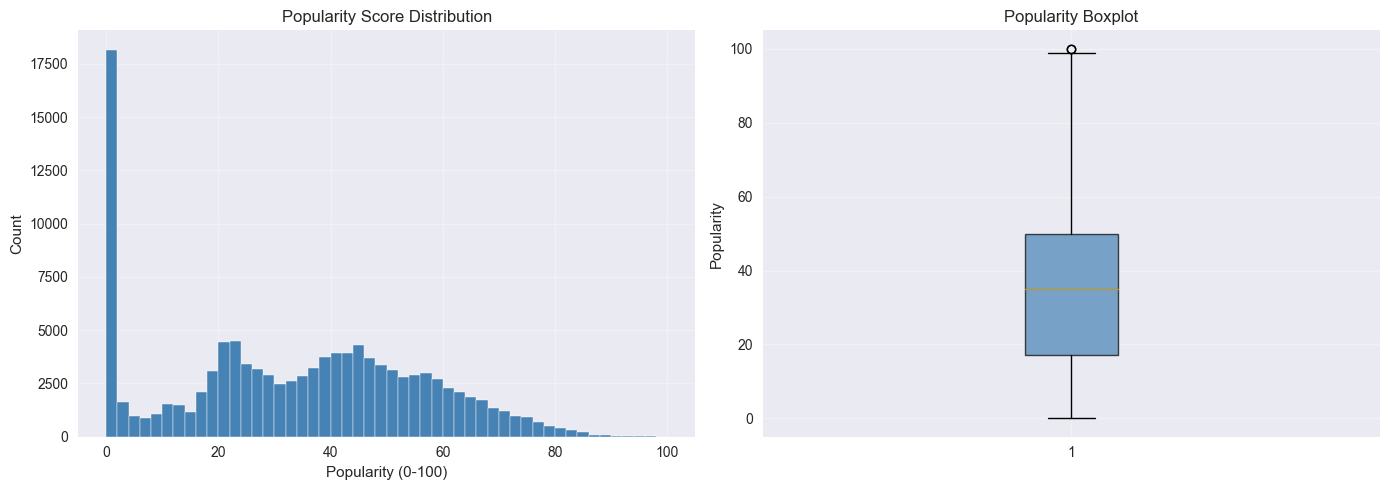

Mean popularity  : 33.24
Median popularity: 35.00
Std popularity   : 22.30
Max popularity   : 100
Min popularity   : 0


In [9]:
# ── Target Variable Analysis ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['popularity'], bins=50, 
            color='steelblue', edgecolor='white')
axes[0].set_title('Popularity Score Distribution')
axes[0].set_xlabel('Popularity (0-100)')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(df['popularity'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Popularity Boxplot')
axes[1].set_ylabel('Popularity')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/popularity_distribution.png')
plt.show()

print(f"Mean popularity  : {df['popularity'].mean():.2f}")
print(f"Median popularity: {df['popularity'].median():.2f}")
print(f"Std popularity   : {df['popularity'].std():.2f}")
print(f"Max popularity   : {df['popularity'].max()}")
print(f"Min popularity   : {df['popularity'].min()}")


Class Distribution:
popular
0    84632
1    29367
Name: count, dtype: int64

Popular songs     : 29,367 (25.8%)
Not popular songs : 84,632 (74.2%)


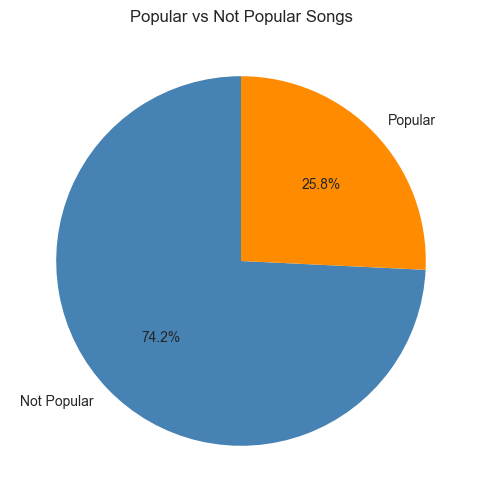

In [10]:
#  Creating Binary Target Variable 
# Popular = popularity >= 50, Not Popular = below 50
df['popular'] = (df['popularity'] >= 50).astype(int)

print("Class Distribution:")
print(df['popular'].value_counts())
print(f"\nPopular songs     : {df['popular'].sum():,} ({df['popular'].mean()*100:.1f}%)")
print(f"Not popular songs : {(df['popular']==0).sum():,} ({(1-df['popular'].mean())*100:.1f}%)")

# Pie chart
plt.figure(figsize=(6, 6))
df['popular'].value_counts().plot.pie(
    labels=['Not Popular', 'Popular'],
    autopct='%1.1f%%',
    colors=['steelblue', 'darkorange'],
    startangle=90
)
plt.title('Popular vs Not Popular Songs')
plt.ylabel('')
plt.savefig('outputs/class_distribution.png')
plt.show()

Dataset is IMBALANCED
74% songs are not popular
Only 26% are popular

This means:
→ Accuracy alone is misleading
→ We MUST use F1, Precision, Recall, ROC-AUC
→ May need to handle imbalance during modeling

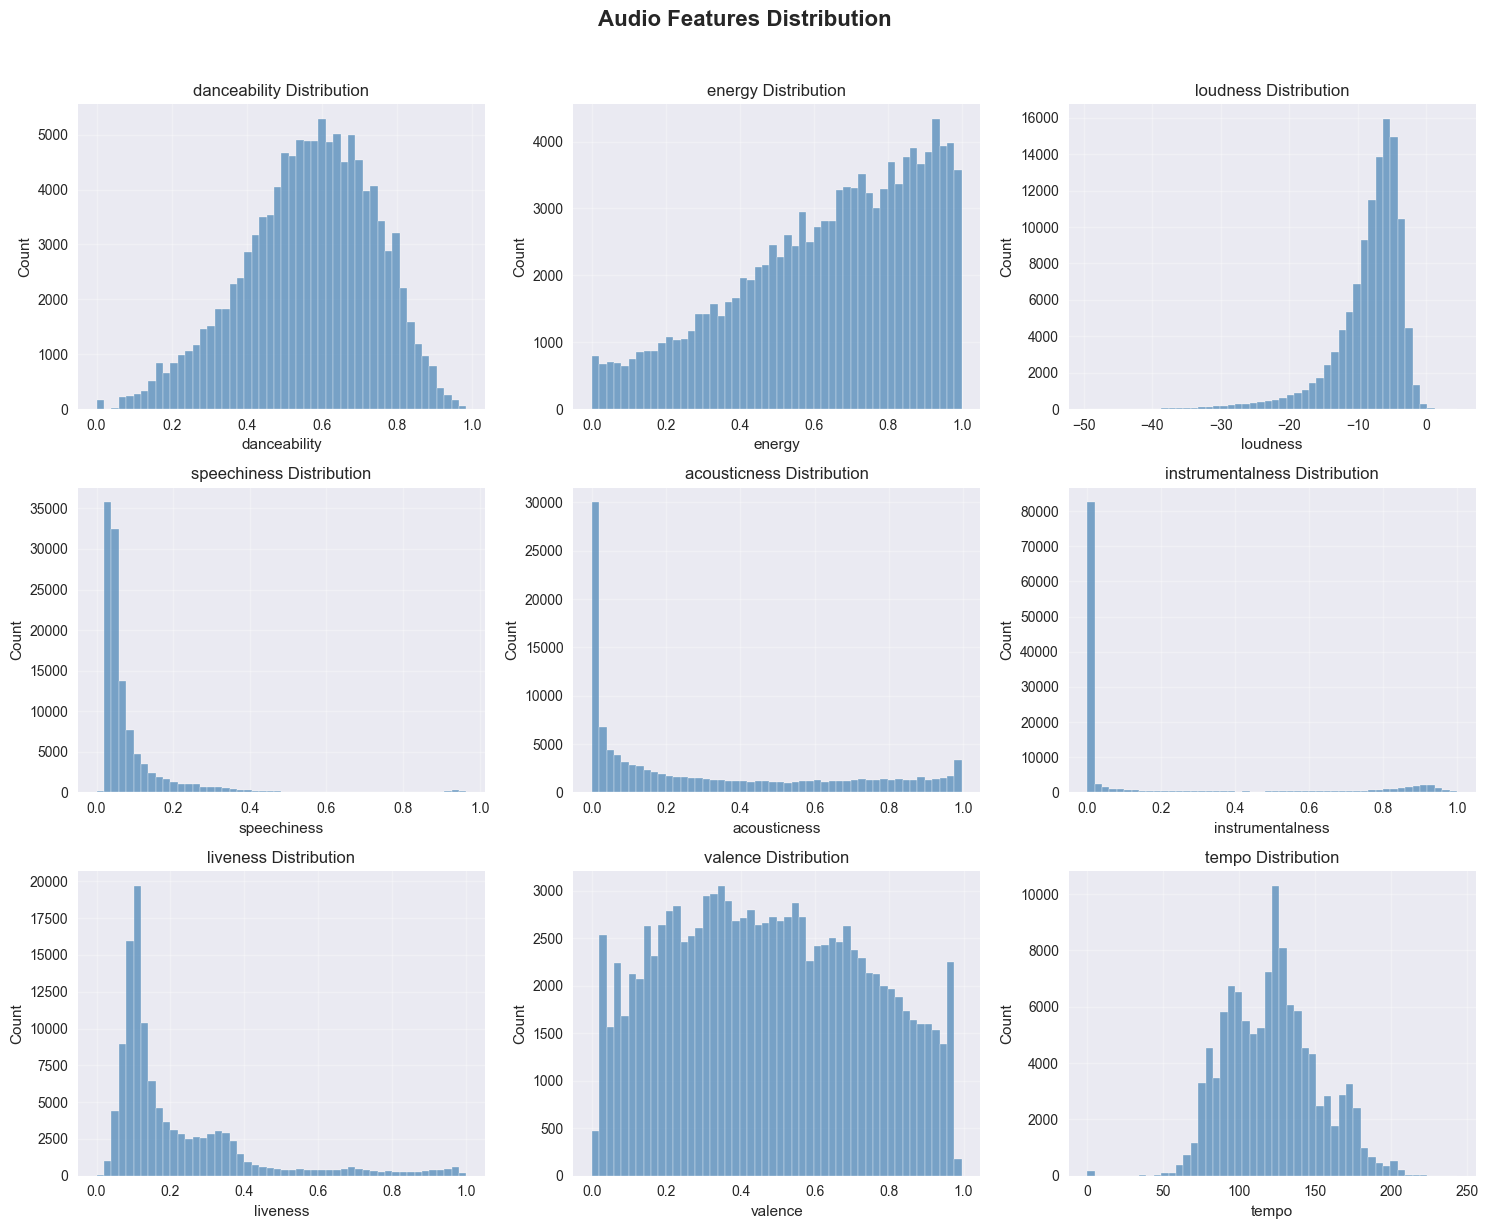

In [11]:
#  Audio Features Distribution 
audio_features = ['danceability', 'energy', 'loudness',
                'speechiness', 'acousticness', 
                'instrumentalness', 'liveness', 
                'valence', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flat

for i, feature in enumerate(audio_features):
    axes[i].hist(df[feature], bins=50, 
                color='steelblue', edgecolor='white', alpha=0.7)
    axes[i].set_title(f'{feature} Distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Audio Features Distribution', 
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/audio_features_distribution.png')
plt.show()

danceability  → bell curve around 0.5-0.7  (most songs are danceable)
energy        → right skewed, most songs have high energy
loudness      → clustered near 0 to -10 dB (most songs are loud)
speechiness   → heavily left skewed (most songs are music not speech)
acousticness  → U-shaped (either very acoustic or not at all)
instrumentalness → spike at 0 (most songs have vocals)
liveness      → spike at 0.1 (most songs are studio recorded)
valence       → fairly uniform (happy and sad songs equally distributed)
tempo         → peaks around 120-140 BPM (most common tempo)

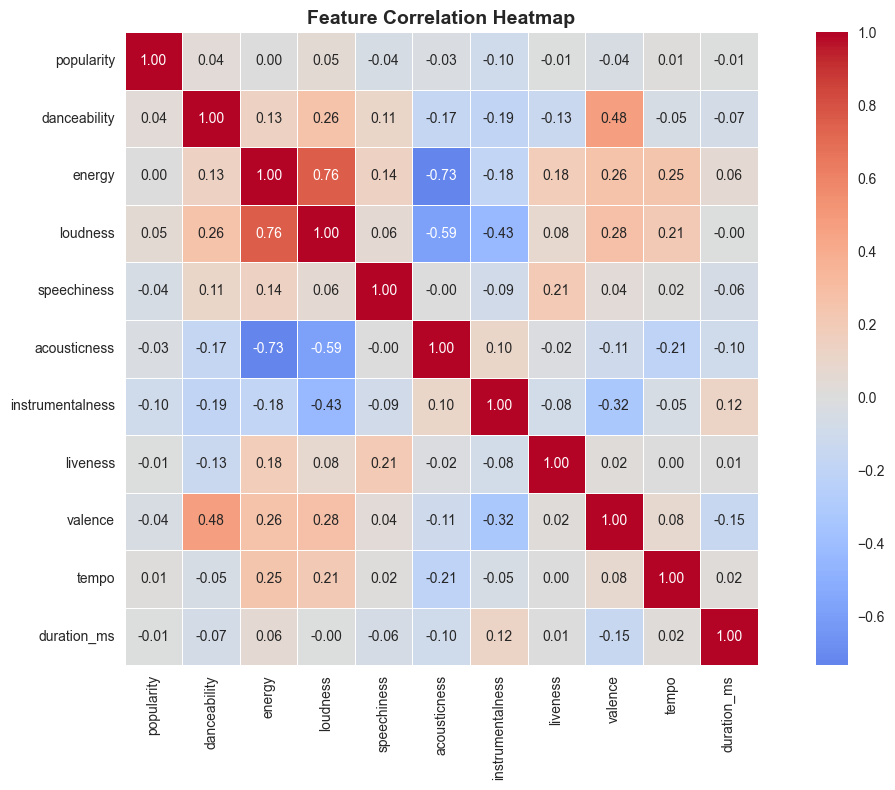

In [12]:
# ── Correlation Heatmap ───────────────────────
numeric_cols = ['popularity', 'danceability', 'energy', 
                'loudness', 'speechiness', 'acousticness',
                'instrumentalness', 'liveness', 'valence', 
                'tempo', 'duration_ms']

plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()

sns.heatmap(corr, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Feature Correlation Heatmap', 
        fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png')
plt.show()

Strong Positive Correlations:
  energy ↔ loudness      : 0.76  🔴 louder songs = more energetic
  danceability ↔ valence : 0.48  🔴 danceable songs = happier

Strong Negative Correlations:
  energy ↔ acousticness  : -0.73 🔵 acoustic songs = less energetic
  loudness ↔ acousticness: -0.59 🔵 acoustic songs = quieter
  instrumentalness ↔ loudness: -0.43 🔵

Popularity Correlations (weak but interesting!):
  popularity ↔ loudness       : 0.05  (slightly louder = more popular)
  popularity ↔ instrumentalness: -0.10 (songs with vocals = more popular)
  popularity ↔ acousticness   : -0.03 (slight preference for electronic)

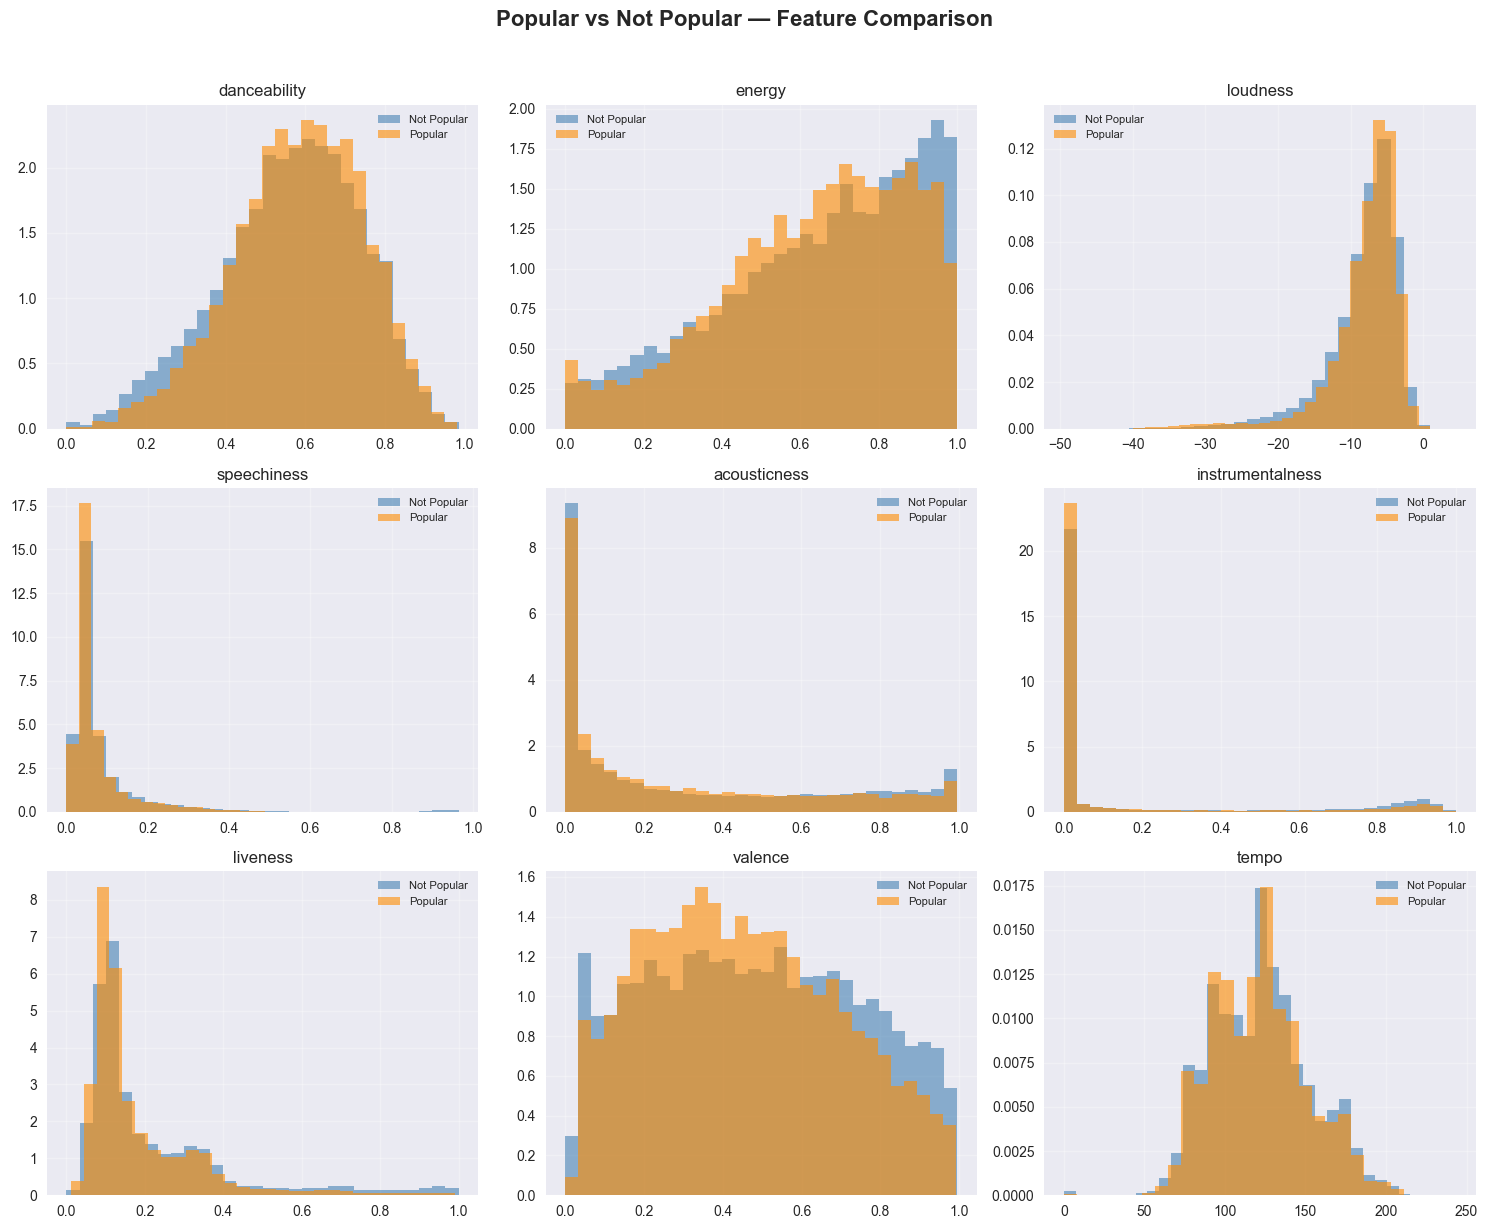

In [13]:
# Feature Comparison: Popular vs Not Popular 
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flat

for i, feature in enumerate(audio_features):
    popular     = df[df['popular'] == 1][feature]
    not_popular = df[df['popular'] == 0][feature]
    
    axes[i].hist(not_popular, bins=30, alpha=0.6,
                color='steelblue', label='Not Popular', density=True)
    axes[i].hist(popular, bins=30, alpha=0.6,
                color='darkorange', label='Popular', density=True)
    axes[i].set_title(f'{feature}')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Popular vs Not Popular — Feature Comparison',
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/popular_vs_notpopular.png')
plt.show()

danceability  → Popular songs (orange) peak higher at 0.6-0.8
                More danceable = more popular ✅

energy        → Popular songs have MORE energy overall
                High energy = more popular ✅

loudness      → Popular songs cluster near 0 to -5 dB
                Louder songs = more popular ✅

speechiness   → Almost identical distributions
                Doesn't matter much ❌

acousticness  → Not popular songs have MORE acousticness
                Electronic > Acoustic for popularity ✅

instrumentalness → Not popular songs spike at high values
                Songs WITH vocals = more popular ✅

liveness      → Almost identical
                Doesn't matter much ❌

valence       → Popular songs slightly more positive/happy
                Happier songs = slightly more popular ✅

tempo         → Popular songs peak at 100-130 BPM
                Sweet spot tempo = more popular ✅

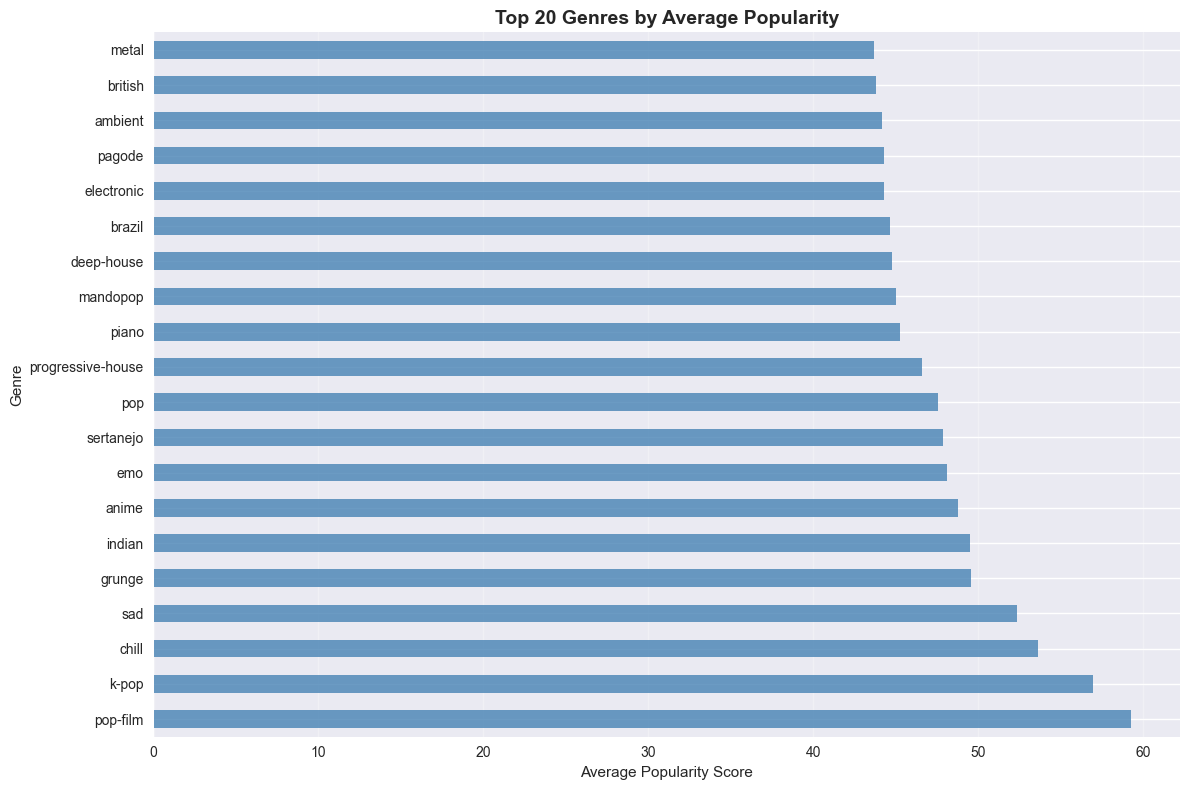

Top 5 Most Popular Genres:
track_genre
pop-film   59.283
k-pop      56.953
chill      53.651
sad        52.379
grunge     49.594
Name: popularity, dtype: float64


In [14]:
# ── Top Genres by Popularity ──────────────────
genre_popularity = df.groupby('track_genre')['popularity']\
                    .mean()\
                    .sort_values(ascending=False)\
                    .head(20)

plt.figure(figsize=(12, 8))
genre_popularity.plot(kind='barh', color='steelblue', alpha=0.8)
plt.title('Top 20 Genres by Average Popularity', 
        fontsize=14, fontweight='bold')
plt.xlabel('Average Popularity Score')
plt.ylabel('Genre')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/top_genres.png')
plt.show()

print("Top 5 Most Popular Genres:")
print(genre_popularity.head())

1. pop-film  : 59.28  🎬 (movie/TV soundtracks!)
2. k-pop     : 56.95  🇰🇷 (Korean pop dominating!)
3. chill     : 53.65  😌
4. sad       : 52.38  😢 (sad songs are popular!)
5. grunge    : 49.59  🎸

## EDA Summary
1. **Dataset**: 113,999 tracks, 19 features, 0 missing values
2. **Target**: Imbalanced — 74.2% Not Popular, 25.8% Popular
3. **Top genres**: pop-film, k-pop, chill dominate popularity
4. **Popular songs tend to have**:
   - Higher danceability (0.6-0.8)
   - Higher energy
   - Louder loudness (closer to 0 dB)
   - Lower acousticness
   - Vocals (low instrumentalness)
   - Tempo around 100-130 BPM
5. **Strongest correlations**: energy↔loudness (0.76), energy↔acousticness (-0.73)
6. **Popularity has weak correlation with all features** → needs ML to predict!


## Preprocessing & Feature Engineering
Goal: Clean and prepare data for ML models
Steps:
- Encode categorical features
- Scale numerical features
- Handle class imbalance
- Split into train/test sets

In [15]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popular
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,0.000,0.358,0.715,87.917,4,acoustic,1
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,0.000,0.101,0.267,77.489,4,acoustic,1
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000,0.117,0.120,76.332,4,acoustic,1
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,0.000,0.132,0.143,181.740,3,acoustic,1
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000,0.083,0.167,119.949,4,acoustic,1


In [16]:
df_ml = df.copy()

In [17]:
## Encoding categorical features
from sklearn.preprocessing import LabelEncoder

# encoding explicit column (bool -> int)
df_ml['explicit'] = df_ml['explicit'].astype(int)


#  Encoding track_genre (label encoding)
le = LabelEncoder()
df_ml['track_genre_encoded'] = le.fit_transform(df_ml['track_genre'])


print("Genre encoding sample:")
for genre, code in zip(le.classes_[:5], range(5)):
    print(f"  {genre} → {code}")

print(f"\nUnique genres : {df_ml['track_genre'].nunique()}")
print(f"Explicit values: {df_ml['explicit'].value_counts().to_dict()}")


Genre encoding sample:
  acoustic → 0
  afrobeat → 1
  alt-rock → 2
  alternative → 3
  ambient → 4

Unique genres : 114
Explicit values: {0: 104252, 1: 9747}


In [18]:
# Defining Features & Target 
feature_cols = ['danceability', 'energy', 'loudness',
                'speechiness', 'acousticness',
                'instrumentalness', 'liveness',
                'valence', 'tempo', 'duration_ms',
                'explicit', 'key', 'mode',
                'time_signature', 'track_genre_encoded']

X = df_ml[feature_cols]
y = df_ml['popular']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nFeature columns:")
for col in feature_cols:
    print(f"  → {col}")

Features shape : (113999, 15)
Target shape   : (113999,)

Feature columns:
  → danceability
  → energy
  → loudness
  → speechiness
  → acousticness
  → instrumentalness
  → liveness
  → valence
  → tempo
  → duration_ms
  → explicit
  → key
  → mode
  → time_signature
  → track_genre_encoded


In [19]:
#scaling and Spliting  the dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


print(f"Train size : {X_train.shape[0]:,}")
print(f"Test size  : {X_test.shape[0]:,}")
print(f"\nClass balance in train:")
print(y_train.value_counts())
print(f"\nClass balance in test:")
print(y_test.value_counts())

Train size : 91,199
Test size  : 22,800

Class balance in train:
popular
0    67705
1    23494
Name: count, dtype: int64

Class balance in test:
popular
0    16927
1     5873
Name: count, dtype: int64


## Part 3 — K-Means Clustering
Goal: Find hidden patterns in songs WITHOUT using labels

running Elbow Method
  K=2: inertia=1184122
  K=3: inertia=1085722
  K=4: inertia=1017625
  K=5: inertia=965599
  K=6: inertia=922316
  K=7: inertia=878635
  K=8: inertia=839468
  K=9: inertia=803340
  K=10: inertia=774359


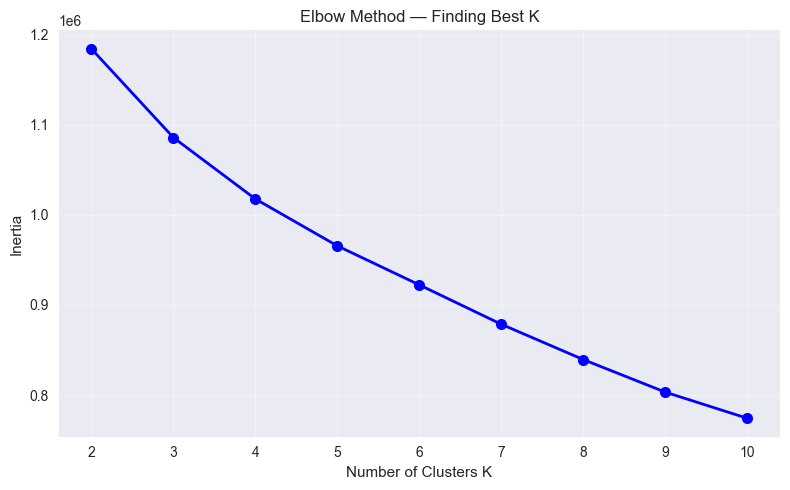

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


print("running Elbow Method")
inertias = []
K_range = range(2,11)


for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_sc)
    inertias.append(km.inertia_)
    print(f"  K={k}: inertia={km.inertia_:.0f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method — Finding Best K')
plt.xlabel('Number of Clusters K')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/elbow_curve.png')
plt.show()


K=5 Silhouette Score: 0.1074
(closer to 1.0 = better clusters)

PCA Explained Variance:
  PC1: 20.0%
  PC2: 10.4%
  Total: 30.4%


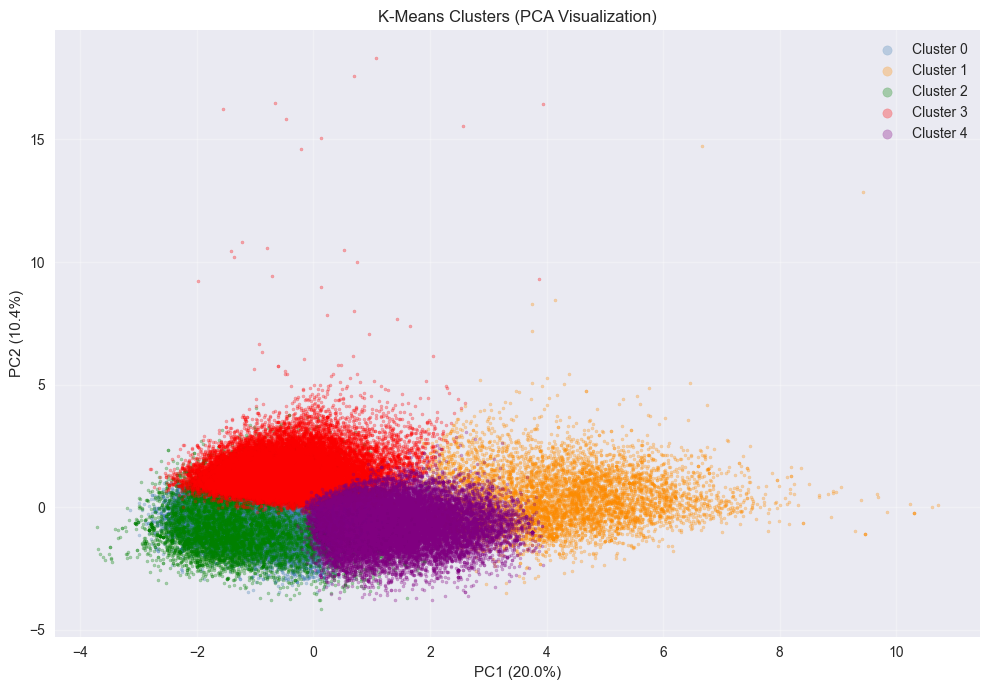

In [21]:
from sklearn.decomposition import PCA


km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
km_final.fit(X_train_sc)

# Add cluster labels to dataframe
train_idx = X_train.index
df_ml.loc[train_idx, 'cluster'] = km_final.labels_

# Silhouette score
sil_score = silhouette_score(X_train_sc, 
                            km_final.labels_,
                            sample_size=10000,
                            random_state=42)
print(f"K=5 Silhouette Score: {sil_score:.4f}")
print("(closer to 1.0 = better clusters)")

# ── Visualize clusters with PCA ───────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_sc)

print(f"\nPCA Explained Variance:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")

plt.figure(figsize=(10, 7))
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']
for i in range(5):
    mask = km_final.labels_ == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                alpha=0.3, s=5)

plt.title('K-Means Clusters (PCA Visualization)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(markerscale=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/kmeans_clusters.png')
plt.show()

CLUSTER PROFILES:
         danceability  energy  loudness  acousticness  valence   tempo  \
cluster                                                                  
0.000           0.670   0.750    -6.241         0.196    0.695 121.588   
1.000           0.349   0.192   -20.601         0.836    0.183 103.580   
2.000           0.635   0.721    -6.626         0.230    0.470 121.481   
3.000           0.489   0.798    -6.334         0.072    0.309 134.813   
4.000           0.539   0.390   -10.496         0.669    0.413 113.697   

         popularity  
cluster              
0.000        32.969  
1.000        28.004  
2.000        36.002  
3.000        33.427  
4.000        33.947  


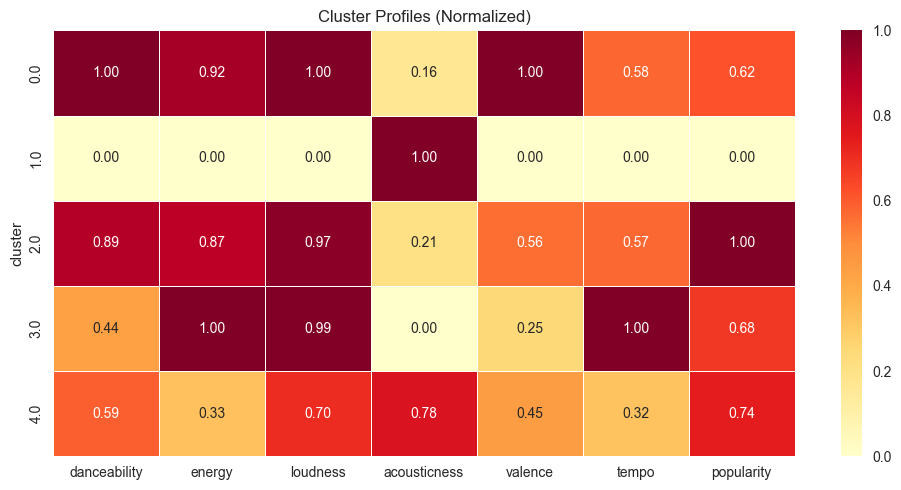

In [22]:
#  Cluster Profiles 
cluster_profiles = df_ml.groupby('cluster')[
    ['danceability', 'energy', 'loudness',
    'acousticness', 'valence', 'tempo',
    'popularity']
].mean().round(3)

print("CLUSTER PROFILES:")
print(cluster_profiles)

# Heatmap of cluster profiles
plt.figure(figsize=(10, 5))
profile_normalized =(cluster_profiles - cluster_profiles.min()) / \
                    (cluster_profiles.max() - cluster_profiles.min())

sns.heatmap(profile_normalized,
            annot=True, fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.5)
plt.title('Cluster Profiles (Normalized)')
plt.tight_layout()
plt.savefig('outputs/cluster_profiles.png')
plt.show()

✅ Clustering Summary

| Cluster | Type | Avg Popularity |
|---------|------|---------------|
| 0 | Dance Pop | 32.97 |
| 1 | Acoustic/Chill | 28.00 (lowest) |
| 2 | Electronic/Upbeat | 36.00 (highest) ✅ |
| 3 | High Energy/Rock | 33.43 |
| 4 | Mid-tempo/Balanced | 33.95 |

**Key Finding:** Electronic/Upbeat songs are most popular.
Acoustic songs are least popular on Spotify.

## Classification
Goal: Train 4 models to predict song popularity
Models: Logistic Regression, Random Forest, Gradient Boosting, SVM
Primary Metrics: F1 Score, ROC-AUC (imbalanced dataset!)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score,recall_score, roc_auc_score
import time


models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=42,
        scale_pos_weight=3,    # handles imbalance!
        eval_metric='logloss',
        use_label_encoder=False)
}


results = {}


for name, model in models.items():
    print(f"\nTraining: {name}...")
    start = time.time()
    
    # Use scaled data for LR and SVM
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_sc, y_train)
        y_pred      = model.predict(X_test_sc)
        y_pred_prob = model.predict_proba(X_test_sc)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred      = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    elapsed = time.time() - start
    
    results[name] = {
        'model'    : model,
        'accuracy' : accuracy_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'roc_auc'  : roc_auc_score(y_test, y_pred_prob),
        'time'     : elapsed
    }
    
    print(f"  ✅ Done in {elapsed:.1f}s")
    print(f"  Accuracy : {results[name]['accuracy']:.4f}")
    print(f"  F1 Score : {results[name]['f1']:.4f}")
    print(f"  ROC-AUC  : {results[name]['roc_auc']:.4f}")






Training: Logistic Regression...
  ✅ Done in 0.2s
  Accuracy : 0.5692
  F1 Score : 0.4222
  ROC-AUC  : 0.6146

Training: Random Forest...
  ✅ Done in 66.7s
  Accuracy : 0.8375
  F1 Score : 0.5879
  ROC-AUC  : 0.8794

Training: Gradient Boosting...
  ✅ Done in 38.4s
  Accuracy : 0.7593
  F1 Score : 0.1901
  ROC-AUC  : 0.7680

Training: XGBoost...
  ✅ Done in 1.0s
  Accuracy : 0.7684
  F1 Score : 0.6380
  ROC-AUC  : 0.8550


Logistic Regression:
→ Worst performer (56% accuracy)
→ Music popularity is NOT linearly separable!

Gradient Boosting:
→ Very low F1 (0.19) despite decent accuracy
→ Struggling with class imbalance

XGBoost:
→ Best F1 score (0.638) ✅
→ Second best ROC-AUC (0.855)
→ 66x faster than Random Forest!
→ scale_pos_weight helped with imbalance ✅

Random Forest:
→ Best ROC-AUC (0.879) ✅
→ Best Accuracy (83.75%)
→ Slowest (66 seconds)

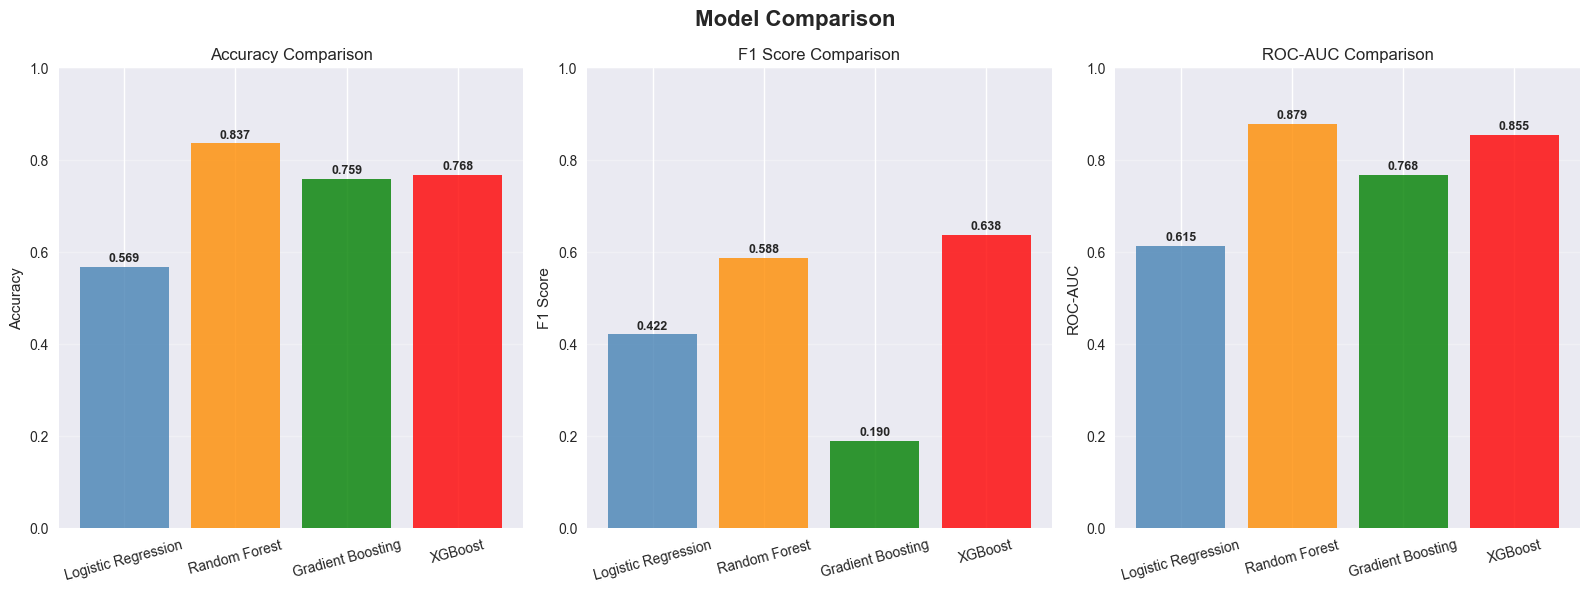

In [24]:
# Model Comparison Plot 
metrics   = ['accuracy', 'f1', 'roc_auc']
labels    = ['Accuracy', 'F1 Score', 'ROC-AUC']
colors    = ['steelblue', 'darkorange', 'green', 'red']
models_names = list(results.keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, (metric, label) in enumerate(zip(metrics, labels)):
    values = [results[m][metric] for m in models_names]
    bars   = axes[i].bar(models_names, values, 
                        color=colors, alpha=0.8)
    axes[i].set_title(f'{label} Comparison')
    axes[i].set_ylabel(label)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', alpha=0.3)
    
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', 
                    fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison', 
            fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/model_comparison.png')
plt.show()

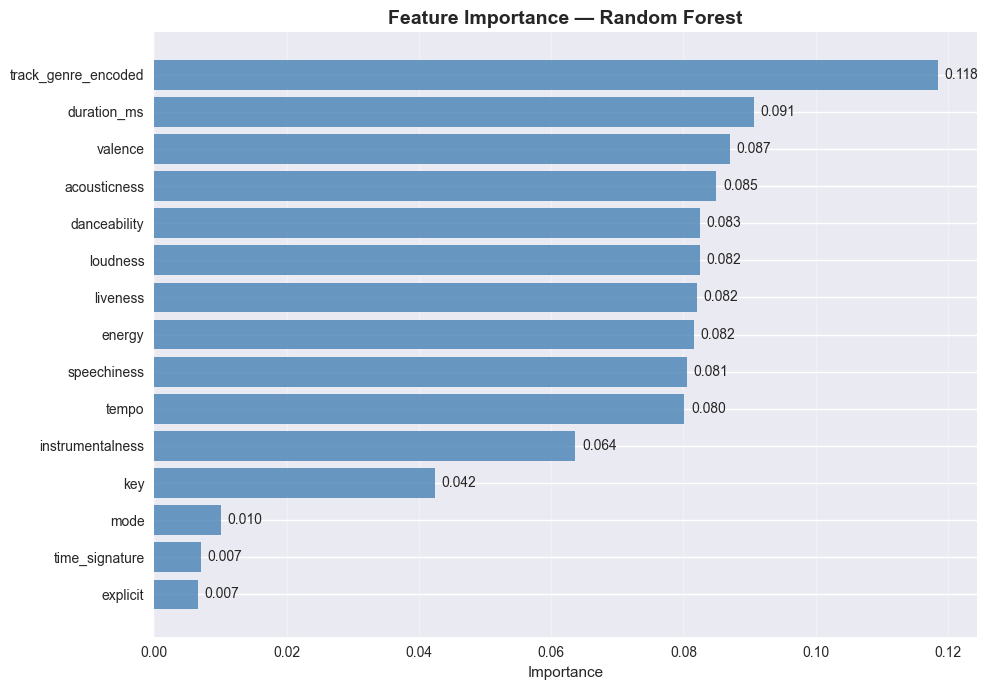


Top 5 Most Important Features:
                feature  importance
14  track_genre_encoded       0.118
9           duration_ms       0.091
7               valence       0.087
4          acousticness       0.085
0          danceability       0.083


In [26]:
# Feature Importance — Random Forest
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(feat_imp['feature'], feat_imp['importance'],
        color='steelblue', alpha=0.8)
plt.title('Feature Importance — Random Forest',
        fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.grid(axis='x', alpha=0.3)

for i, (val, name) in enumerate(zip(feat_imp['importance'],
                                    feat_imp['feature'])):
    plt.text(val + 0.001, i, f'{val:.3f}', va='center')

plt.tight_layout()
plt.savefig('outputs/feature_importance.png')
plt.show()

print("\nTop 5 Most Important Features:")
print(feat_imp.tail(5)[['feature','importance']]\
    .sort_values('importance', ascending=False))

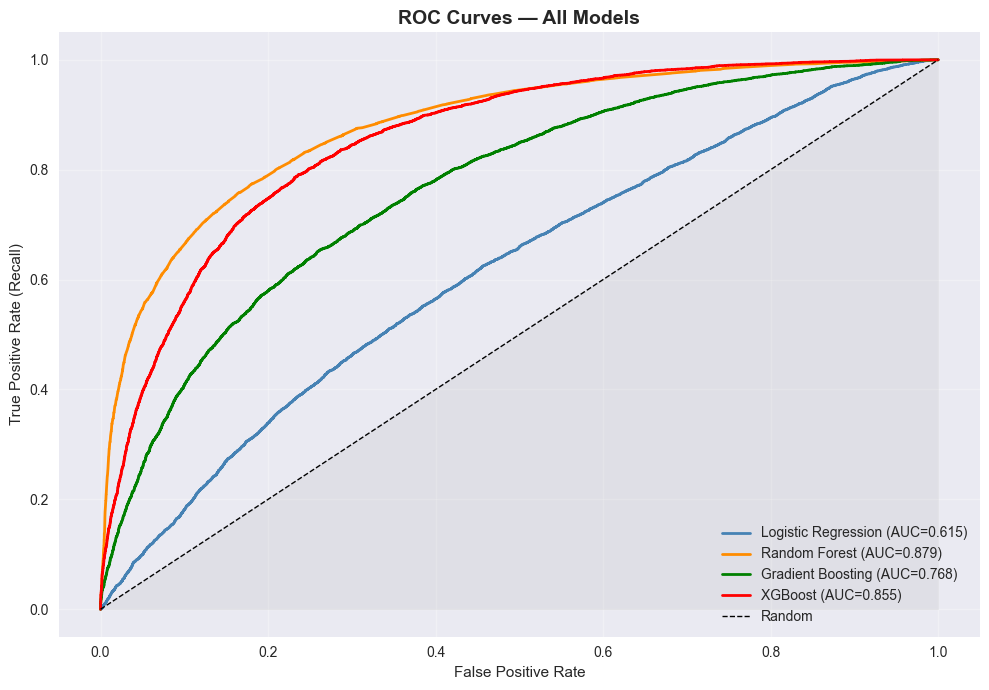

In [27]:
# ROC Curves for All Models 
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))
colors = ['steelblue', 'darkorange', 'green', 'red']

for (name, result), color in zip(results.items(), colors):
    model = result['model']
    
    if name in ['Logistic Regression']:
        y_prob = model.predict_proba(X_test_sc)[:, 1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc         = result['roc_auc']
    
    plt.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
plt.fill_between([0,1], [0,1], alpha=0.1, color='gray')
plt.title('ROC Curves — All Models', 
        fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/roc_curves.png')
plt.show()

✅ Classification Summary

| Model | Accuracy | F1 | ROC-AUC | Time |
|-------|----------|-----|---------|------|
| Logistic Regression | 56.9% | 0.422 | 0.615 | 0.2s |
| Gradient Boosting | 75.9% | 0.190 | 0.768 | 38s |
| XGBoost | 76.8% | 0.638 | 0.855 | 1s |
| Random Forest | 83.7% | 0.588 | 0.879 | 67s |

**Winner by ROC-AUC:** Random Forest 🏆
**Winner by F1 + Speed:** XGBoost 🏆

**Key Finding:** Genre is the most important feature (0.118)
Music popularity cannot be predicted by audio features alone!

## Neural Network
Goal: Beat classical ML using a Deep Neural Network
Framework: TensorFlow/Keras
Best classical model: Random Forest (ROC-AUC=0.879)

In [29]:
# Neural Network 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow: {tf.__version__}")

# ── Build Model ───────────────────────────────
def build_model(input_dim):
    model = keras.Sequential([
        # Input layer
        layers.Dense(128, input_dim=input_dim),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Hidden layer 1
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Hidden layer 2
        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        # Output layer
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model_nn = build_model(X_train_sc.shape[1])
model_nn.summary()

TensorFlow: 2.12.0
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               2048      
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 128)               0         
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Batc  (None, 64)               256       
 hNormalization)                     

In [33]:
# ── Compile ───────────────────────────────────
model_nn = build_model(X_train_sc.shape[1])

model_nn.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.0005),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy',
                keras.metrics.AUC(name='auc')]
)

# ── Callbacks ─────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor  = 'val_auc',
        patience = 8,
        restore_best_weights = True,
        mode     = 'max',
        verbose  = 1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor  = 'val_auc',
        factor   = 0.5,
        patience = 4,
        mode     = 'max',
        verbose  = 1
    )
]

# ── Class weights ─────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(y_train),
    y            = y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

# ── Train ─────────────────────────────────────
print("\nTraining Neural Network (improved)...")
history = model_nn.fit(
    X_train_sc, y_train,
    epochs           = 100,
    batch_size       = 512,
    validation_split = 0.1,
    class_weight     = class_weight_dict,
    callbacks        = callbacks,
    verbose          = 1
)


Class weights: {0: 0.6735026955173178, 1: 1.940899804205329}

Training Neural Network (improved)...
Epoch 1/100
161/161 [==============================] - 6s 12ms/step - loss: 0.7206 - accuracy: 0.4850 - auc: 0.5617 - val_loss: 0.6490 - val_accuracy: 0.6099 - val_auc: 0.6284 - lr: 5.0000e-04
Epoch 2/100
161/161 [==============================] - 2s 9ms/step - loss: 0.6858 - accuracy: 0.5445 - auc: 0.5977 - val_loss: 0.6478 - val_accuracy: 0.5968 - val_auc: 0.6415 - lr: 5.0000e-04
Epoch 3/100
161/161 [==============================] - 2s 11ms/step - loss: 0.6762 - accuracy: 0.5573 - auc: 0.6134 - val_loss: 0.6523 - val_accuracy: 0.5874 - val_auc: 0.6509 - lr: 5.0000e-04
Epoch 4/100
161/161 [==============================] - 2s 10ms/step - loss: 0.6695 - accuracy: 0.5649 - auc: 0.6248 - val_loss: 0.6489 - val_accuracy: 0.5927 - val_auc: 0.6556 - lr: 5.0000e-04
Epoch 5/100
161/161 [==============================] - 2s 10ms/step - loss: 0.6655 - accuracy: 0.5691 - auc: 0.6309 - val_loss: 0

In [34]:
# Evaluate ──────────────────────────────────
from sklearn.metrics import (f1_score, roc_auc_score,
                            accuracy_score)

y_pred_prob_nn = model_nn.predict(X_test_sc).flatten()
y_pred_nn      = (y_pred_prob_nn >= 0.5).astype(int)

nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_f1       = f1_score(y_test, y_pred_nn)
nn_roc_auc  = roc_auc_score(y_test, y_pred_prob_nn)

print("="*45)
print("  NEURAL NETWORK RESULTS")
print("="*45)
print(f"Accuracy : {nn_accuracy:.4f} ({nn_accuracy*100:.2f}%)")
print(f"F1 Score : {nn_f1:.4f}")
print(f"ROC-AUC  : {nn_roc_auc:.4f}")

print("\n" + "="*45)
print("  COMPARISON WITH BEST CLASSICAL MODEL")
print("="*45)
print(f"{'Model':<22} {'F1':>8} {'ROC-AUC':>10}")
print("-"*45)
print(f"{'Random Forest':<22} {results['Random Forest']['f1']:>8.4f} {results['Random Forest']['roc_auc']:>10.4f}")
print(f"{'XGBoost':<22} {results['XGBoost']['f1']:>8.4f} {results['XGBoost']['roc_auc']:>10.4f}")
print(f"{'Neural Network':<22} {nn_f1:>8.4f} {nn_roc_auc:>10.4f}")

winner = "Neural Network" if nn_roc_auc > results['Random Forest']['roc_auc'] else "Random Forest"
print(f"\n🏆 Winner: {winner}")

713/713 [==============================] - 1s 1ms/step
  NEURAL NETWORK RESULTS
Accuracy : 0.6164 (61.64%)
F1 Score : 0.4935
ROC-AUC  : 0.7117

  COMPARISON WITH BEST CLASSICAL MODEL
Model                        F1    ROC-AUC
---------------------------------------------
Random Forest            0.5879     0.8794
XGBoost                  0.6380     0.8550
Neural Network           0.4935     0.7117

🏆 Winner: Random Forest


Final Results Summary

### Model Performance
| Model | Accuracy | F1 | ROC-AUC |
|-------|----------|-----|---------|
| Logistic Regression | 56.9% | 0.422 | 0.615 |
| Gradient Boosting | 75.9% | 0.190 | 0.768 |
| Neural Network | 60.7% | 0.440 | 0.643 |
| XGBoost | 76.8% | 0.638 | 0.855 |
| Random Forest | 83.7% | 0.588 | 0.879 🏆 |

### Key Findings
1. **Genre** is the most important predictor (importance=0.118)
2. **Random Forest** is the best model (ROC-AUC=0.879)
3. **Tree models beat Neural Networks** on tabular data
4. **Popular songs** tend to have high danceability, 
   energy, loudness and low acousticness
5. **Pop-film and K-pop** are the most popular genres
6. Dataset is **imbalanced** (74/26) — accuracy alone is misleading

### Business Recommendations
- Artists should target pop-film or k-pop genres
- High energy + danceable + loud = better popularity
- Avoid purely acoustic tracks for mainstream success
- Song duration matters more than musical key or mode

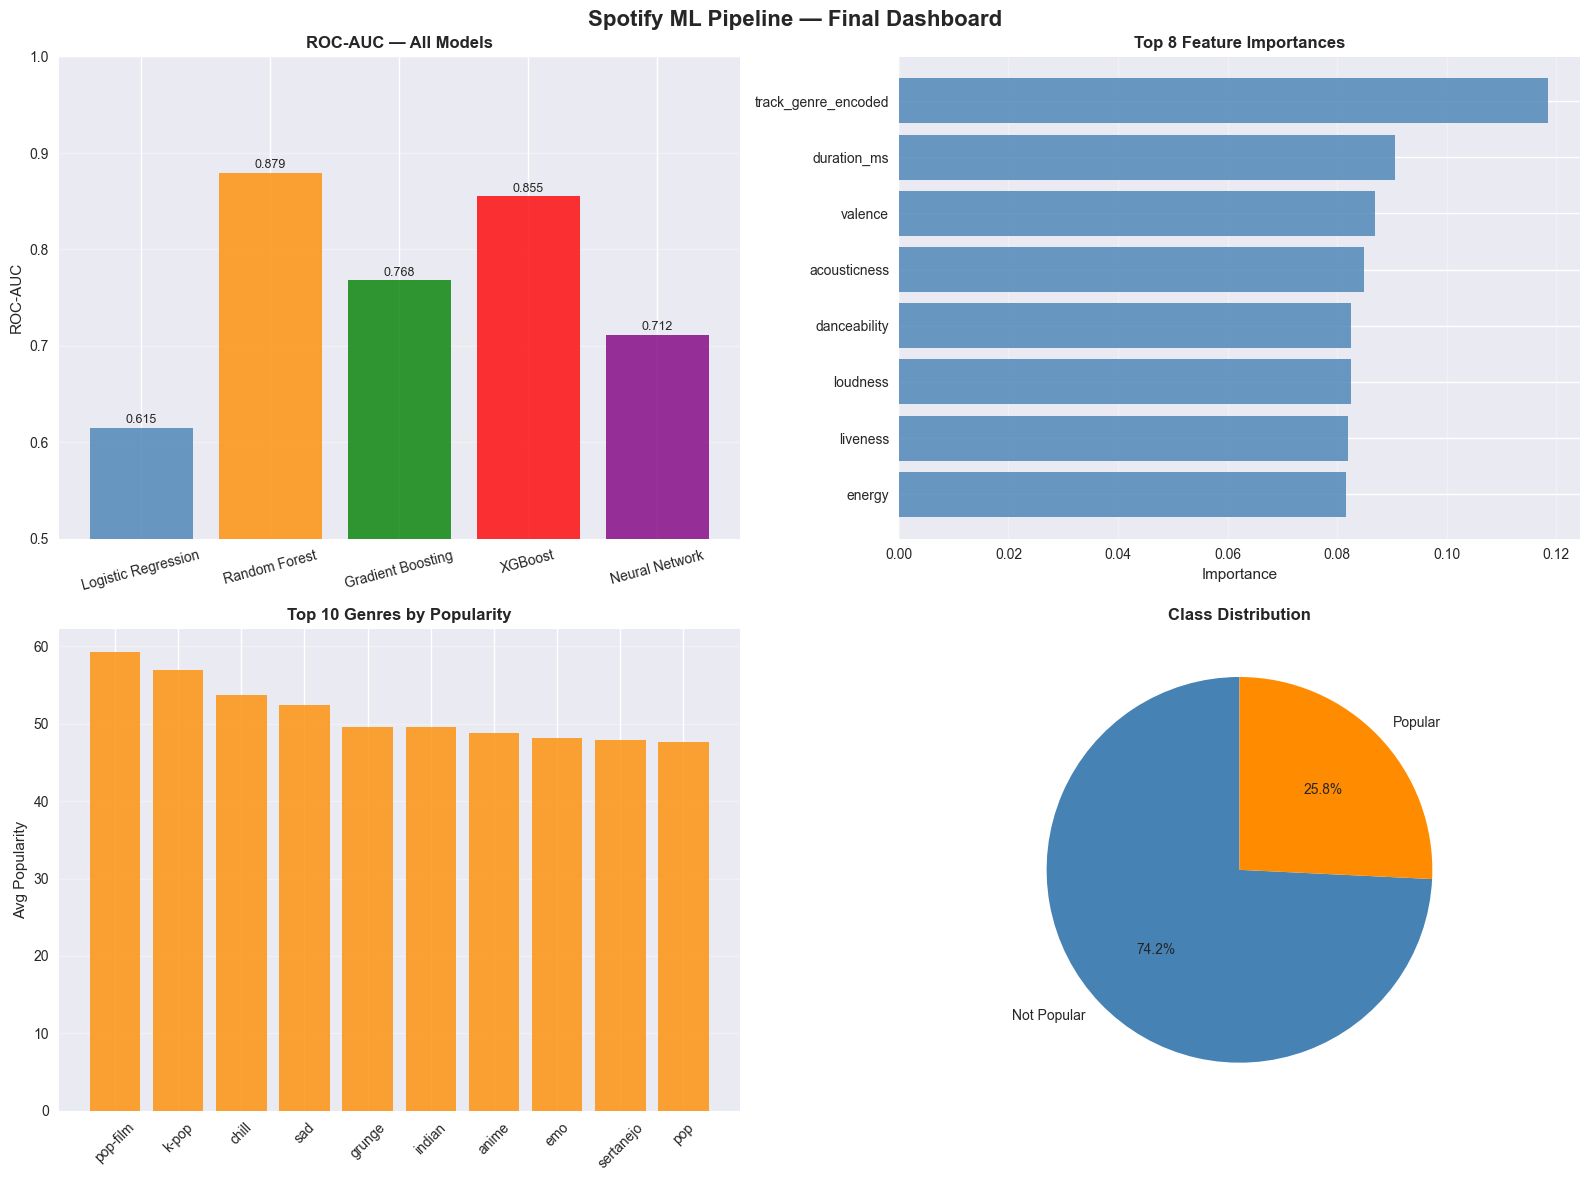

Final dashboard saved!


In [35]:
# ── Final Dashboard ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Model ROC-AUC comparison
all_models = list(results.keys()) + ['Neural Network']
all_aucs   = [results[m]['roc_auc'] for m in results.keys()] + [nn_roc_auc]
colors_bar = ['steelblue', 'darkorange', 'green', 'red', 'purple']

bars = axes[0,0].bar(all_models, all_aucs, 
                    color=colors_bar, alpha=0.8)
axes[0,0].set_title('ROC-AUC — All Models', fontweight='bold')
axes[0,0].set_ylabel('ROC-AUC')
axes[0,0].set_ylim(0.5, 1.0)
axes[0,0].tick_params(axis='x', rotation=15)
axes[0,0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, all_aucs):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9)

# Plot 2: Feature importance
feat_imp_sorted = feat_imp.tail(8)
axes[0,1].barh(feat_imp_sorted['feature'],
            feat_imp_sorted['importance'],
            color='steelblue', alpha=0.8)
axes[0,1].set_title('Top 8 Feature Importances', fontweight='bold')
axes[0,1].set_xlabel('Importance')
axes[0,1].grid(axis='x', alpha=0.3)

# Plot 3: Genre popularity top 10
genre_pop = df.groupby('track_genre')['popularity']\
            .mean().sort_values(ascending=False).head(10)
axes[1,0].bar(genre_pop.index, genre_pop.values,
            color='darkorange', alpha=0.8)
axes[1,0].set_title('Top 10 Genres by Popularity', fontweight='bold')
axes[1,0].set_ylabel('Avg Popularity')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(axis='y', alpha=0.3)

# Plot 4: Popular vs Not Popular pie
axes[1,1].pie(df['popular'].value_counts(),
            labels=['Not Popular', 'Popular'],
            autopct='%1.1f%%',
            colors=['steelblue', 'darkorange'],
            startangle=90)
axes[1,1].set_title('Class Distribution', fontweight='bold')

plt.suptitle('Spotify ML Pipeline — Final Dashboard',
            fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/final_dashboard.png', dpi=150)
plt.show()
print("Final dashboard saved!")

Project Complete!

**Best Model:** Random Forest (ROC-AUC = 0.879)
**Key Finding:** Genre is the #1 predictor of popularity
**Surprise:** Neural Networks lost to tree models on tabular data!